# Regression Disconuity Design - Incumbency Advantage In US Elections

In this notebook I will explain and evaluate regression discontinuity designs for estimating causal effects. To do this I will be replicating a study by Lee (2008). 

Regression discontinuity designs (RDDs) exploit natural experiments in the environment. They rely on the fact that a treatment is performed upon a unit when the attribute of a unit crosses a certain threshold. It is assumed that close to either side of the threshold units are similar with the only difference being whether they received the treatment or not. Therefore, the difference in some variables of interest between the groups close to threshold is the causal effect of the treatment. It can be show that with some reasonable assumption RDD can be as reliable as randomised controlled trials (Lee 2008). How amazing! We can get results as good as RCTs by exploiting some fact about our enviroment. However, a note of caution, for the RDD estimate to be non-biased some assumptions must be true (all of which are not testable) and furthermore, we must interpret the result correctly (see the assumptions and implementation sections below) 

In this notebook we apply RDDs to studying the incumbency advantage. By incumbency advantage we mean the fact that incumbents in the US House Representatives are much more likely to be relected. Lee (2008) states that the relection rate of incumbents is about 90% and has been stable over the last 50 years. RDDs can be applied to study the incumbency advantage because we know the threshold at which a candidate recieves the treatment of being an incumbent, it is when vote count is 50%. Therefore, if the assumptions of RDD hold, then the difference in votes received at the next election by incumbents who just won their district vs candidates who just lost their district in the previous election will give the causal effect of incumbency on vote share received.

Some quick notation for the rest of the notebook. Each inidividual $i$ has vote share at the next election of $Y$, if they are the incumbent they receive $Y^{1}$ if not they recieve $Y^{0}$. Each individual also has a set of covariates $X_{i}$ which contains the *running variable* $V_{i}$ (last election vote share in this context), when $V_{i} > v_{0}$ (last election vote share is greater than 0.5) the individual recieves the treatment (becomes the incumbent).


# Assumptions of RDD

RDDs assume the following (Lemieux & Imbens 2008):

1. $E[Y^{0} | V=v] \text{ and } E[Y^{1} | V=v] \text{ are continous in } v$

2. $F_{Y^{0} | v}(y|v) \text{ and } F_{Y^{1} | v}(y|v) \text{ are continuous in } c$

These assumptions are actually stronger than required as actually we only require continuity at the threshold value $V=v_{0}$. If these assumptions are true they are telling us the individuals just below the threshold are a good counterfactual for individuals just above the threshold. For example, looking at assumption 1, If the conditional expectation of $Y_{0}|V$ is continuous (especially at the threshold) it means we can assume if the individuals who did not recieve the treatment scored just above $v_{0}$ and still did not recieve the treatment their outcome would not change much (only by $\frac{dY^{0}|V}{dV}$) and therefore, we assume this is what individuals who score just above threshold would have obtained had they not recieved the treatment.

**Important** Notice that there is however a problem here. What does it mean for an individual to get more than 50% of the vote and not be elected? There is no reality where this happens. The potential outcomes framework does not allow us to describe this design very logically. Lee (2008) actually changes the assumptions slightly. We drop the potential outcomes notation assume that the outcome is a function of the attributes of each unit and the treatment. The outcome must be continuous in the treatment, except at the discontinuity. Further, the distribution of the running variable conditional on the covariates is continuous at $v_{0}$. Again this is just to make sure that either side of the discontinuity can be considered reasonable counterfactuals for each other. Mathematically if the assumptions hold we have,

$$
\int^{\infty}_{-\infty}(y^{+}(x) - y^{-}(x)\frac{f(0|x)}{f(0)}dG(w))
$$
$$
= ATE^{**}
$$

$ATE^{**}$ is thw weighted average of individual-specific discontinuity gaps (Lee 2008).



# Implementation and Interpretation of RDD

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from lee_data import get_data

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data

- explain dataset
- explain data structure (columns are not very clearn)



In [6]:
df = get_data("individ_final.dta")
df.head()

,yearel,myoutcome,second,myoutcomenext,use,difshare,difgrp,mmyoutcomenext,mrunagain,mofficeexp,melectexp,mpmyoutcomenext,mprunagain,mpofficeexp,mpelectexp
0,1946.0,1.0,NaN,0.0,NaN,0.061488,212.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1946.0,0.0,1.0,0.0,1.0,-0.061488,187.0,0.107143,0.214286,2.053571,2.339286,0.069917,0.285555,0.671483,0.932918
2,1948.0,1.0,NaN,1.0,1.0,0.104869,220.0,0.743590,0.871795,3.256410,3.461539,0.749363,0.869388,2.650860,2.872225
3,1948.0,0.0,1.0,0.0,NaN,-0.104869,179.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1948.0,0.0,NaN,0.0,NaN,-0.535721,92.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Visualise the discontinuity

Scatter plots of vote share in previous election x, vote share in this election y showing the jump at x>50



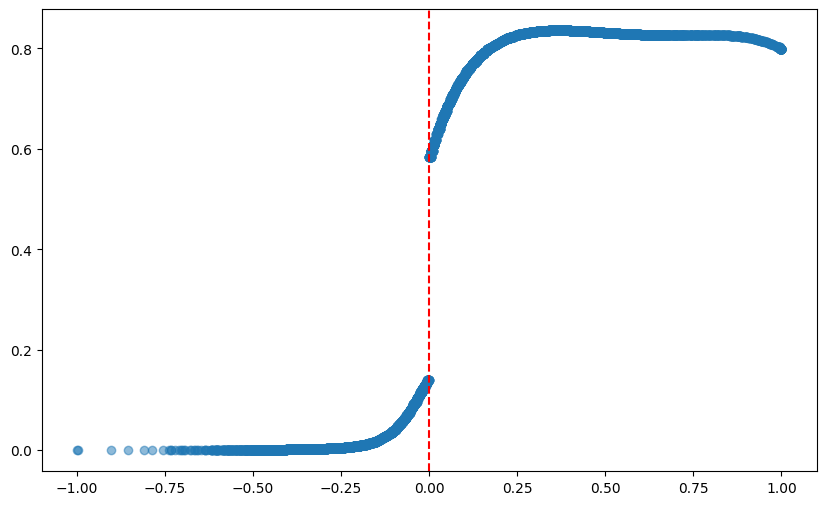

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['difshare'], df['mpmyoutcomenext'], alpha=0.5)
ax.axvline(0, color='red', linestyle='--')

# Naive Mean Difference Estimator

Why don't we just compute the difference between average vote share obtained by incumbents against the same value for non-incumbents and call this the incumbency advantage? 

# Regression Discontinuity

Implement RDD 

Discuss the results

Include evaluations check if assumtpions are met

# Bibliography

Lee 2008